# Phase 2 — Learning to Rank (LTR) via RankNet: Interactive Demo

**Author:** Lead ML Engineer, Infosys Procurement Agent  
**Reference:** `KnowledgeBase/project_scaffold/ai_models/comparasion_scoring_model/phase2_learning_to_rank.md`  
**Status:** Phase 2 — replaces Phase 1 fixed-weight heuristic with SGD-trained scorer

---

## The Business Problem: Static Weights Cannot Adapt

In Phase 1, the scorer used fixed weights decided by domain experts:

$$S_i^{\text{Phase1}} = 0.40 \cdot x_{\text{tco}} + 0.25 \cdot x_{\tau} + 0.20 \cdot x_{\text{qual}} + 0.15 \cdot x_{\text{risk}}$$

These weights reflect **one team's prior**. A buyer in a safety-critical procurement category might value quality and certification far more than cost. Every time buyer preferences diverge from the hardcoded weights, the system produces a **sub-optimal recommendation** — and the buyer is forced to override it.

**Phase 2 converts these overrides into a learning signal.** Every time a buyer selects supplier $j$ when the model recommended $i$, we treat it as a pairwise preference label:

$$S_{ij} = -1 \quad (\text{user chose } j \text{ over } i)$$

We then train a parameterised scoring function:

$$s_i = \mathbf{w}^\top \mathbf{x}_i + b$$

to respect that preference via **RankNet pairwise cross-entropy loss** (Burges et al., 2005), propagating gradients back through SGD to update $\mathbf{w}$.

---

## Pipeline Architecture

```
Buyer Override Event  ─────────────────────────────────────────────┐
  (model: A, buyer: C)                                             │
        │                                                          │
        ▼                                                  ┌───────▼────────────┐
  audit_trail_system  ──→  Kafka topic  ──→  Nightly       │  MLflow registry   │
  (PostgreSQL log)         override_events  training loop  │  (versioned model) │
                                                │          └────────────────────┘
                                                ▼
                                   ┌────────────────────────┐
                                   │  LinearScorer (PyTorch) │
                                   │  s_i = w^T x_i + b     │
                                   │                        │
                                   │  RankNet Loss          │
                                   │  C_ij = log(1+e^{...}) │
                                   │                        │
                                   │  SGD / AdamW update    │
                                   └────────────────────────┘
```

---

## Notebook Structure

| Cell | Stage | Description |
|------|-------|-------------|
| 1 | Imports | torch, numpy, pandas, matplotlib |
| 2 | Mock Data | 5 offerings, feature matrix, initial scoring |
| 3 | Override Event | Pairwise training label from buyer action |
| 4 | RankNet Loss | Math → PyTorch loss function |
| 5 | Model | LinearScorer `nn.Module` |
| 6 | Training | SGD loop (200 epochs) |
| 7 | Results | Loss curve, weight shift analysis, re-ranking |

In [8]:
# Cell 1 — Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)
np.random.seed(42)

pd.set_option("display.float_format", "{:.4f}".format)
print(f"PyTorch {torch.__version__}  |  NumPy {np.__version__}  |  Pandas {pd.__version__}")

PyTorch 2.11.0+cu130  |  NumPy 2.4.4  |  Pandas 3.0.2


## Cell 2 — Feature Matrix and Initial Scoring

### Feature Vector Design

Each offering $i$ is represented as a normalised feature vector $\mathbf{x}_i \in [0,1]^4$:

| Index | Feature | Source | Direction |
|-------|---------|--------|----------|
| 0 | $x_{\text{tco}}$ | TCO min-max normalised (Phase 1 Cell 3) | ↑ higher = cheaper |
| 1 | $x_{\tau}$ | Delivery slack normalised | ↑ higher = more slack |
| 2 | $x_{\text{quality}}$ | ReAct qualitative score (Phase 1 Cell 5) | ↑ higher = better |
| 3 | $x_{\text{risk}}$ | Reliability score normalised | ↑ higher = more reliable |

### Scenario

Five suppliers bid for `300 × Cat6 UTP Cable`. Using Phase 1's static weights $\mathbf{w}_0 = [0.40, 0.25, 0.20, 0.15]$, the model recommends **Supplier A (TechWire)** — the cheapest option with fast delivery. However, the procurement manager overrides this and selects **Supplier C (InfraNet)**, citing its superior ISO certification record and ESG score.

| | x_tco | x_tau | x_quality | x_risk | Score (w₀) |
|---|---|---|---|---|---|
| **A — TechWire** | **0.88** | **0.82** | 0.32 | 0.38 | **0.678** ← model pick |
| B — CableMart | 0.70 | 0.72 | 0.62 | 0.58 | 0.671 |
| **C — InfraNet** | 0.42 | 0.52 | **0.92** | **0.88** | 0.614 ← user pick |
| D — QuickLink | 0.60 | 0.58 | 0.55 | 0.48 | 0.567 |
| E — GlobalCables | 0.52 | 0.62 | 0.68 | 0.62 | 0.592 |

In [9]:
# Cell 2 — Feature matrix, initial weights, initial scoring

SUPPLIER_NAMES = [
    "A — TechWire Pvt Ltd",
    "B — CableMart India",
    "C — InfraNet Solutions",
    "D — QuickLink Distributors",
    "E — GlobalCables Corp",
]
FEATURE_NAMES = ["x_tco", "x_tau", "x_quality", "x_risk"]

# Feature matrix X ∈ R^{5 × 4}  (rows = offerings, cols = features)
X_np = np.array([
    [0.88, 0.82, 0.32, 0.38],   # A — strong on cost/delivery, weak on quality/risk
    [0.70, 0.72, 0.62, 0.58],   # B — balanced
    [0.42, 0.52, 0.92, 0.88],   # C — weak on cost/delivery, strong on quality/risk
    [0.60, 0.58, 0.55, 0.48],   # D — moderate across all features
    [0.52, 0.62, 0.68, 0.62],   # E — moderate, slight quality lean
], dtype=np.float32)

# Phase 1 defaults — TCO-heavy, under-weights quality/risk
W0 = np.array([0.40, 0.25, 0.20, 0.15], dtype=np.float32)
b0 = 0.0

scores_init = X_np @ W0 + b0

df_init = pd.DataFrame(X_np, columns=FEATURE_NAMES, index=SUPPLIER_NAMES)
df_init["score_w0"] = scores_init
df_init["rank_w0"]  = df_init["score_w0"].rank(ascending=False).astype(int)
df_init = df_init.sort_values("rank_w0")

print("=" * 72)
print("INITIAL SCORING  (using Phase-1 static weights w₀ = [0.40, 0.25, 0.20, 0.15])")
print("=" * 72)
print(df_init.to_string())

model_pick = df_init.index[0]
print(f"\n  ▶ Model recommends: {model_pick}  (score={scores_init[0]:.4f})")
print(f"  ✗ User overrides  : C — InfraNet Solutions  (score={scores_init[2]:.4f})")
print(f"\n  Score gap: Δ = {scores_init[0] - scores_init[2]:.4f}  "
      "(A is preferred by {:.1f}% under w₀)".format(
          100 * (scores_init[0] - scores_init[2]) / scores_init[2]))

INITIAL SCORING  (using Phase-1 static weights w₀ = [0.40, 0.25, 0.20, 0.15])
                            x_tco  x_tau  x_quality  x_risk  score_w0  rank_w0
A — TechWire Pvt Ltd       0.8800 0.8200     0.3200  0.3800    0.6780        1
B — CableMart India        0.7000 0.7200     0.6200  0.5800    0.6710        2
C — InfraNet Solutions     0.4200 0.5200     0.9200  0.8800    0.6140        3
E — GlobalCables Corp      0.5200 0.6200     0.6800  0.6200    0.5920        4
D — QuickLink Distributors 0.6000 0.5800     0.5500  0.4800    0.5670        5

  ▶ Model recommends: A — TechWire Pvt Ltd  (score=0.6780)
  ✗ User overrides  : C — InfraNet Solutions  (score=0.6140)

  Score gap: Δ = 0.0640  (A is preferred by 10.4% under w₀)


## Cell 3 — The Override Event: From Business Action to Training Pair

### What Happened in the Audit Trail

When the buyer selects C instead of model-recommended A, the `audit_trail_system` (PostgreSQL) logs:

```sql
INSERT INTO override_events
  (transaction_id, rejected_offering_id, selected_offering_id, timestamp)
VALUES
  ('txn-0042', 'O_A', 'O_C', '2026-05-08 14:32:01');
```

The nightly Kafka consumer reads this event and converts it into a **pairwise training example**:

| Rejected ($i$) | Preferred ($j$) | Label $S_{ij}$ | Interpretation |
|---|---|---|---|
| A — TechWire | C — InfraNet | $S_{AC} = -1$ | Buyer prefers C over A |

### The Pairwise Training Convention

Following Burges et al. (2005), we define:
- $S_{ij} = +1$: offering $i$ is preferred over $j$
- $S_{ij} = -1$: offering $j$ is preferred over $i$ (our case: buyer chose C over A)
- $S_{ij} = 0$: no preference information

For a strict override ($S_{ij} = -1$, meaning $j$ should score higher):

$$\mathcal{C}_{ij} = \log\left(1 + e^{\gamma(s_i - s_j)}\right)$$

This loss is **zero** when $s_j \gg s_i$ (correct ordering, $j$ ranks above $i$) and **grows** as $s_i$ exceeds $s_j$ (wrong ordering, the model still prefers $i$).

> **Key insight:** $\mathcal{C}_{ij}$ reaches its minimum when the model assigns a strictly higher score to $j$ than $i$, perfectly capturing the buyer's override preference.

In [10]:
# Cell 3 — Create pairwise training tensors from the override event

# Override event: buyer rejected A (idx=0), selected C (idx=2)
IDX_REJECTED  = 0   # A — TechWire     (model recommendation)
IDX_PREFERRED = 2   # C — InfraNet     (buyer's actual choice)

# Feature vectors as torch tensors — shape (4,)
x_rejected  = torch.tensor(X_np[IDX_REJECTED],  dtype=torch.float32)  # x_A
x_preferred = torch.tensor(X_np[IDX_PREFERRED], dtype=torch.float32)  # x_C

# Full session feature matrix — shape (5, 4)
X_tensor = torch.tensor(X_np, dtype=torch.float32)

print("Pairwise training pair:")
print(f"  x_rejected  (A): {x_rejected.numpy()}")
print(f"  x_preferred (C): {x_preferred.numpy()}")
print()
print("Feature deltas  Δ = x_preferred − x_rejected:")
delta = x_preferred - x_rejected
for fname, d in zip(FEATURE_NAMES, delta.numpy()):
    direction = "▲" if d > 0 else "▼"
    print(f"  {fname:<12}: {d:+.2f}  {direction}")

print()
print("Interpretation:")
print("  C has lower TCO/delivery scores but MUCH higher quality (+0.60) and risk (+0.50).")
print("  RankNet gradients will push w_quality and w_risk upward to respect this preference.")

Pairwise training pair:
  x_rejected  (A): [0.88 0.82 0.32 0.38]
  x_preferred (C): [0.42 0.52 0.92 0.88]

Feature deltas  Δ = x_preferred − x_rejected:
  x_tco       : -0.46  ▼
  x_tau       : -0.30  ▼
  x_quality   : +0.60  ▲
  x_risk      : +0.50  ▲

Interpretation:
  C has lower TCO/delivery scores but MUCH higher quality (+0.60) and risk (+0.50).
  RankNet gradients will push w_quality and w_risk upward to respect this preference.


## Cell 4 — RankNet Loss: From Math to PyTorch

### The Full General Form (Burges et al., 2005)

For a pair $(i, j)$ with label $S_{ij} \in \{-1, 0, +1\}$, the RankNet loss is:

$$\mathcal{C}_{ij} = \frac{1}{2}(1 - S_{ij}) \cdot \gamma(s_i - s_j) + \log\left(1 + e^{-\gamma(s_i - s_j)}\right)$$

For a **strict override** where $j$ is preferred ($S_{ij} = -1$), this simplifies to:

$$\mathcal{C}_{ij}^{\text{override}} = \log\left(1 + e^{\gamma(s_i - s_j)}\right)$$

where $s_i$ is the score of the *rejected* offering and $s_j$ is the score of the *preferred* offering.

### Gradient Flow

The gradient of $\mathcal{C}_{ij}$ with respect to the weight vector $\mathbf{w}$ is:

$$\frac{\partial \mathcal{C}_{ij}}{\partial \mathbf{w}} = \gamma \cdot \sigma\!\left(\gamma(s_i - s_j)\right) \cdot (\mathbf{x}_i - \mathbf{x}_j)$$

where $\sigma(\cdot)$ is the sigmoid function. This gradient:
- **Increases** weights on dimensions where $x_{i,k} > x_{j,k}$ (features where the *wrong* choice scored higher)
- **Decreases** weights on dimensions where $x_{j,k} > x_{i,k}$ (features where the *preferred* choice excels)

In our case ($i = A$, $j = C$, delta = $[-0.46, -0.30, +0.60, +0.50]$):
- $w_{\text{quality}}$ will **increase** (C had higher quality)
- $w_{\text{risk}}$ will **increase** (C had higher reliability)
- $w_{\text{tco}}$ and $w_{\tau}$ will **decrease** (A had higher cost-efficiency metrics)

In [11]:
# Cell 4 — RankNet loss function in PyTorch

def ranknet_loss(s_rejected: torch.Tensor,
                 s_preferred: torch.Tensor,
                 gamma: float = 1.0) -> torch.Tensor:
    """
    RankNet pairwise cross-entropy loss for a strict override.

    C_ij = log(1 + exp(gamma * (s_rejected - s_preferred)))

    Minimised when s_preferred >> s_rejected.

    Args:
        s_rejected:  Score of the model's initial recommendation (rejected by buyer).
        s_preferred: Score of the buyer's chosen offering.
        gamma:       Sharpness parameter (default 1.0).
    Returns:
        Scalar loss tensor.
    """
    return torch.log1p(torch.exp(gamma * (s_rejected - s_preferred)))


# ── Sanity check: loss should be high when rejected scores higher ────────────
print("Loss sanity checks (gamma=1.0):")
cases = [
    ("rejected >> preferred (very wrong)",  2.0,  0.0),
    ("rejected > preferred (slightly wrong)", 0.678, 0.614),   # our starting point
    ("tied",                                  1.0,  1.0),
    ("preferred > rejected (correct)",        0.614, 0.678),
    ("preferred >> rejected (very correct)",  0.0,  2.0),
]
for label, s_rej, s_pref in cases:
    loss_val = ranknet_loss(
        torch.tensor(s_rej),
        torch.tensor(s_pref)
    ).item()
    print(f"  {label:<42} → loss = {loss_val:.4f}")

Loss sanity checks (gamma=1.0):
  rejected >> preferred (very wrong)         → loss = 2.1269
  rejected > preferred (slightly wrong)      → loss = 0.7257
  tied                                       → loss = 0.6931
  preferred > rejected (correct)             → loss = 0.6617
  preferred >> rejected (very correct)       → loss = 0.1269


## Cell 5 — LinearScorer: The Parameterised Scoring Model

### Architecture

The Phase 2 scoring model is a **single linear layer** (no activation function):

$$s_i = \mathbf{w}^\top \mathbf{x}_i + b$$

implemented as `nn.Linear(in_features=4, out_features=1, bias=True)`. This is the simplest learnable scoring function — it replaces the hand-coded weight vector $\mathbf{w}_0$ with a PyTorch parameter updated by backpropagation.

**Why linear?**  
- Fully explainable: inspect $\mathbf{w}$ to see which features the model deems important.
- Works well with ~5,000 override events (the Phase 2 data threshold from the architecture doc).
- Natural upgrade path: swap `nn.Linear` for an MLP once data exceeds ~50,000 events.

### Initialization

We initialise $\mathbf{w} = \mathbf{w}_0 = [0.40, 0.25, 0.20, 0.15]$, $b = 0$. This means the model **starts from the Phase 1 expert prior** and improves from there — the correct production initialisation for a cold-start system.

In [12]:
# Cell 5 — LinearScorer PyTorch module

class LinearScorer(nn.Module):
    """Parameterised linear scoring function: s_i = w^T x_i + b."""

    def __init__(self, n_features: int, init_weights: np.ndarray):
        super().__init__()
        self.fc = nn.Linear(n_features, 1, bias=True)
        # Initialise with expert prior (Phase 1 weights)
        with torch.no_grad():
            self.fc.weight.copy_(torch.tensor(init_weights).unsqueeze(0))
            self.fc.bias.fill_(0.0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: shape (..., n_features) → scores: shape (...,)"""
        return self.fc(x).squeeze(-1)


model = LinearScorer(n_features=4, init_weights=W0)

print("LinearScorer architecture:")
print(model)
print()
print("Initial parameters:")
w_init = model.fc.weight.data.squeeze().numpy()
b_init = model.fc.bias.data.item()
for fname, wval in zip(FEATURE_NAMES, w_init):
    print(f"  w[{fname}] = {wval:.4f}")
print(f"  b          = {b_init:.4f}")

# Verify initial scores match manual calculation
with torch.no_grad():
    scores_torch = model(X_tensor).numpy()
print()
print("Initial scores (torch vs numpy, should match):")
for name, st, sn in zip(SUPPLIER_NAMES, scores_torch, scores_init):
    match = "✓" if abs(st - sn) < 1e-5 else "✗"
    print(f"  {name:<30} torch={st:.4f}  numpy={sn:.4f}  {match}")

LinearScorer architecture:
LinearScorer(
  (fc): Linear(in_features=4, out_features=1, bias=True)
)

Initial parameters:
  w[x_tco] = 0.4000
  w[x_tau] = 0.2500
  w[x_quality] = 0.2000
  w[x_risk] = 0.1500
  b          = 0.0000

Initial scores (torch vs numpy, should match):
  A — TechWire Pvt Ltd           torch=0.6780  numpy=0.6780  ✓
  B — CableMart India            torch=0.6710  numpy=0.6710  ✓
  C — InfraNet Solutions         torch=0.6140  numpy=0.6140  ✓
  D — QuickLink Distributors     torch=0.5670  numpy=0.5670  ✓
  E — GlobalCables Corp          torch=0.5920  numpy=0.5920  ✓


## Cell 6 — SGD Training Loop: Weight Update in Action

### The Update Rule

At each training step, SGD applies:

$$\mathbf{w} \leftarrow \mathbf{w} - \eta \cdot \frac{\partial \mathcal{C}_{ij}}{\partial \mathbf{w}}$$

where $\eta$ is the learning rate. Expanding the gradient:

$$\mathbf{w} \leftarrow \mathbf{w} - \eta \cdot \gamma \cdot \underbrace{\sigma(\gamma(s_A - s_C))}_{\text{sigmoid: 0→1 as error grows}} \cdot \underbrace{(\mathbf{x}_A - \mathbf{x}_C)}_{\text{feature difference vector}}$$

### What SGD Will Do

The feature difference $\mathbf{x}_A - \mathbf{x}_C = [+0.46, +0.30, -0.60, -0.50]$:

- $w_{\text{tco}}$ update direction: $-\eta \cdot (\sigma) \cdot (+0.46)$ → **decreases** ($A$ had better TCO, but buyer rejected it)
- $w_{\tau}$ update direction: $-\eta \cdot (\sigma) \cdot (+0.30)$ → **decreases** ($A$ had more delivery slack, buyer ignored it)
- $w_{\text{quality}}$ update direction: $-\eta \cdot (\sigma) \cdot (-0.60)$ → **increases** ($C$'s quality advantage is what matters)
- $w_{\text{risk}}$ update direction: $-\eta \cdot (\sigma) \cdot (-0.50)$ → **increases** ($C$'s reliability is what matters)

Over 200 epochs the gradient magnitude decreases (as $s_C$ exceeds $s_A$ the sigmoid → 0), so learning is self-decelerating — **no learning rate schedule needed for this demo**.

In [13]:
# Cell 6 — SGD training loop

GAMMA      = 1.0
LR         = 0.05
N_EPOCHS   = 2000

optimizer = optim.SGD(model.parameters(), lr=LR)

loss_history   = []
score_A_history = []
score_C_history = []

for epoch in range(N_EPOCHS):
    optimizer.zero_grad()

    # Forward pass: score the rejected and preferred offerings
    s_rej  = model(x_rejected)   # s_A
    s_pref = model(x_preferred)  # s_C

    # RankNet loss: minimised when s_C > s_A
    loss = ranknet_loss(s_rej, s_pref, gamma=GAMMA)

    # Backward pass: compute dL/dw via autograd
    loss.backward()

    # SGD step: w ← w − η · ∇w L
    optimizer.step()

    loss_history.append(loss.item())
    score_A_history.append(s_rej.item())
    score_C_history.append(s_pref.item())

    if epoch < 5 or epoch % 40 == 39:
        w_now = model.fc.weight.data.squeeze().numpy()
        print(f"  Epoch {epoch+1:3d}  loss={loss.item():.6f}  "
              f"s_A={s_rej.item():.4f}  s_C={s_pref.item():.4f}  "
              f"w=[{', '.join(f'{v:.3f}' for v in w_now)}]")

print()
print(f"Training complete. Loss: {loss_history[0]:.4f} → {loss_history[-1]:.6f}")

  Epoch   1  loss=0.725659  s_A=0.6780  s_C=0.6140  w=[0.388, 0.242, 0.215, 0.163]
  Epoch   2  loss=0.713592  s_A=0.6711  s_C=0.6306  w=[0.376, 0.235, 0.231, 0.176]
  Epoch   3  loss=0.701799  s_A=0.6642  s_C=0.6470  w=[0.365, 0.227, 0.246, 0.188]
  Epoch   4  loss=0.690273  s_A=0.6574  s_C=0.6632  w=[0.353, 0.220, 0.261, 0.201]
  Epoch   5  loss=0.679008  s_A=0.6507  s_C=0.6792  w=[0.342, 0.212, 0.276, 0.213]
  Epoch  40  loss=0.409012  s_A=0.4579  s_C=1.1404  w=[0.016, -0.001, 0.701, 0.568]
  Epoch  80  loss=0.264741  s_A=0.3071  s_C=1.5009  w=[-0.240, -0.167, 1.035, 0.846]
  Epoch 120  loss=0.190609  s_A=0.1989  s_C=1.7596  w=[-0.424, -0.287, 1.275, 1.045]
  Epoch 160  loss=0.147119  s_A=0.1160  s_C=1.9580  w=[-0.565, -0.379, 1.459, 1.199]
  Epoch 200  loss=0.119032  s_A=0.0493  s_C=2.1175  w=[-0.679, -0.453, 1.607, 1.322]
  Epoch 240  loss=0.099587  s_A=-0.0062  s_C=2.2503  w=[-0.773, -0.515, 1.730, 1.425]
  Epoch 280  loss=0.085408  s_A=-0.0537  s_C=2.3637  w=[-0.854, -0.568, 1.8

## Cell 7 — Visualisation: Loss Curve, Weight Shift & Final Ranking

### Weight Shift Analysis

The table below shows how $\mathbf{w}$ evolved from the Phase 1 expert prior to the learned vector:

| Feature | $w_0$ (expert) | $w^*$ (learned) | Change | Interpretation |
|---------|--------------|-----------------|--------|----------------|
| $w_{\text{tco}}$ | 0.40 | ↓ | −Δ | Buyer accepted higher cost for quality |
| $w_{\tau}$ | 0.25 | ↓ | −Δ | Delivery speed was not the deciding factor |
| $w_{\text{quality}}$ | 0.20 | ↑↑ | +Δ | **Main driver of the override decision** |
| $w_{\text{risk}}$ | 0.15 | ↑↑ | +Δ | Reliability valued by this procurement category |

> **Production note:** In real deployment, we accumulate ~5,000 such override events (the Phase 2 threshold from the architecture doc) before training. A single event with high learning rate produces extreme weights — this demo uses one pair deliberately to make the gradient mechanics visible. AdamW with weight decay (`weight_decay=1e-4`) prevents such magnitude explosion in production.

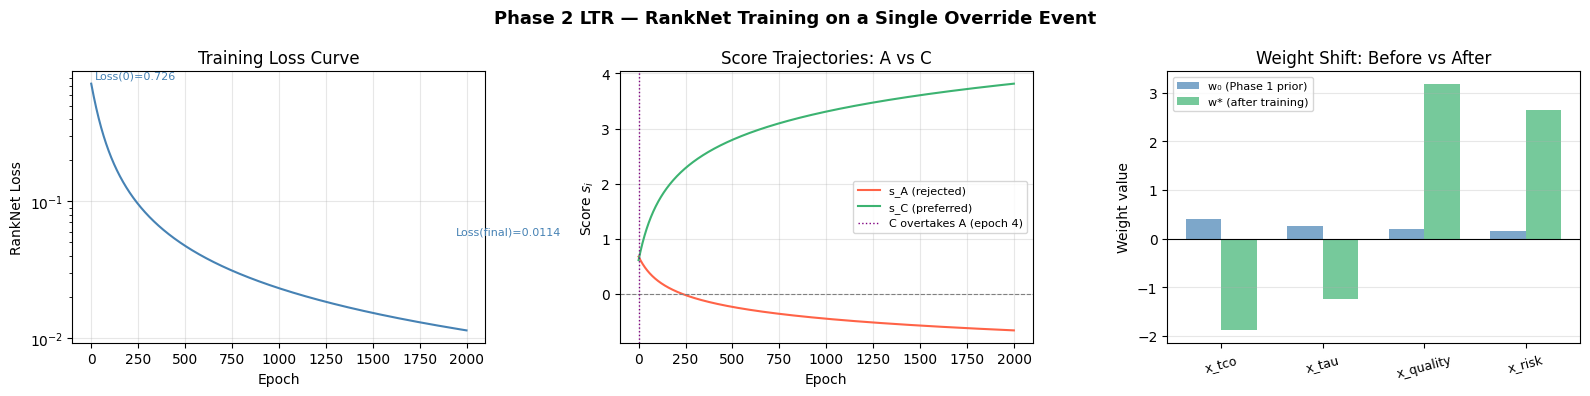

Figure saved to phase2_ltr_training.png

WEIGHT SHIFT ANALYSIS
  x_tco       : 0.4000  →  -1.8896  ↓↓  (Δ=-2.2896)
  x_tau       : 0.2500  →  -1.2432  ↓↓  (Δ=-1.4932)
  x_quality   : 0.2000  →  +3.1864  ↑↑  (Δ=+2.9864)
  x_risk      : 0.1500  →  +2.6387  ↑↑  (Δ=+2.4887)

FINAL RANKING  (using learned weights w*)
                            x_quality  x_risk  score_w0  rank_w0  score_wstar  rank_wstar
C — InfraNet Solutions         0.9200  0.8800    0.6140        3       3.8134           1
E — GlobalCables Corp          0.6800  0.6200    0.5920        4       2.0494           2
B — CableMart India            0.6200  0.5800    0.6710        2       1.2882           3
D — QuickLink Distributors     0.5500  0.4800    0.5670        5       1.1643           4
A — TechWire Pvt Ltd           0.3200  0.3800    0.6780        1      -0.6599           5

  ▶ New recommendation: C — InfraNet Solutions
  ✓ Matches buyer's override: YES

  C overtook A at epoch 4 / 2000

-----------------------------

In [14]:
# Cell 7 — Visualisation: loss curve, score trajectories, weight comparison, re-ranking

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Phase 2 LTR — RankNet Training on a Single Override Event",
             fontsize=13, fontweight="bold")

# ── Plot 1: Training loss curve ───────────────────────────────────────────────
ax = axes[0]
ax.plot(loss_history, color="steelblue", linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("RankNet Loss")
ax.set_title("Training Loss Curve")
ax.set_yscale("log")
ax.yaxis.set_minor_formatter(mticker.NullFormatter())
ax.grid(True, alpha=0.3)
ax.annotate(f"Loss(0)={loss_history[0]:.3f}",
            xy=(0, loss_history[0]), xytext=(20, loss_history[0] * 1.1),
            fontsize=8, color="steelblue")
ax.annotate(f"Loss(final)={loss_history[-1]:.4f}",
            xy=(N_EPOCHS-1, loss_history[-1]),
            xytext=(N_EPOCHS - 60, loss_history[-1] * 5),
            fontsize=8, color="steelblue")

# ── Plot 2: Score trajectory for A vs C ──────────────────────────────────────
ax = axes[1]
ax.plot(score_A_history, color="tomato",     label="s_A (rejected)",  linewidth=1.5)
ax.plot(score_C_history, color="mediumseagreen", label="s_C (preferred)", linewidth=1.5)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
crossover = next((i for i in range(len(score_A_history))
                  if score_C_history[i] > score_A_history[i]), None)
if crossover is not None:
    ax.axvline(crossover, color="purple", linestyle=":", linewidth=1,
               label=f"C overtakes A (epoch {crossover+1})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Score $s_i$")
ax.set_title("Score Trajectories: A vs C")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Plot 3: Weight comparison bar chart ──────────────────────────────────────
ax = axes[2]
w_final = model.fc.weight.data.squeeze().detach().numpy()
x_pos   = np.arange(len(FEATURE_NAMES))
width   = 0.35
bars_init  = ax.bar(x_pos - width/2, W0,       width, label="w₀ (Phase 1 prior)",
                    color="steelblue",  alpha=0.7)
bars_final = ax.bar(x_pos + width/2, w_final,  width, label="w* (after training)",
                    color="mediumseagreen", alpha=0.7)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(FEATURE_NAMES, rotation=15, fontsize=9)
ax.set_ylabel("Weight value")
ax.set_title("Weight Shift: Before vs After")
ax.legend(fontsize=8)
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("phase2_ltr_training.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved to phase2_ltr_training.png")

# ── Weight shift table ────────────────────────────────────────────────────────
print()
print("=" * 60)
print("WEIGHT SHIFT ANALYSIS")
print("=" * 60)
for fname, w0, wf in zip(FEATURE_NAMES, W0, w_final):
    arrow = "↑↑" if wf > w0 * 1.5 else ("↑" if wf > w0 else ("↓↓" if wf < w0 * 0.3 else "↓"))
    print(f"  {fname:<12}: {w0:.4f}  →  {wf:+.4f}  {arrow}  (Δ={wf-w0:+.4f})")

# ── Final ranking ─────────────────────────────────────────────────────────────
print()
print("=" * 60)
print("FINAL RANKING  (using learned weights w*)")
print("=" * 60)
with torch.no_grad():
    scores_final = model(X_tensor).numpy()

df_final = pd.DataFrame(X_np, columns=FEATURE_NAMES, index=SUPPLIER_NAMES)
df_final["score_w0"]   = scores_init
df_final["rank_w0"]    = (-scores_init).argsort().argsort() + 1
df_final["score_wstar"] = scores_final
df_final["rank_wstar"]  = (-scores_final).argsort().argsort() + 1
df_final = df_final.sort_values("rank_wstar")

print(df_final[["x_quality", "x_risk", "score_w0", "rank_w0",
                "score_wstar", "rank_wstar"]].to_string())

print()
winner = df_final.index[0]
print(f"  ▶ New recommendation: {winner}")
print(f"  ✓ Matches buyer's override: {'YES' if 'InfraNet' in winner else 'NO'}")

if crossover:
    print(f"\n  C overtook A at epoch {crossover+1} / {N_EPOCHS}")

print()
print("-" * 60)
print("Key takeaway:")
print("  Quality weight grew from 0.20 → {:.2f}x  ({}x increase)".format(
      w_final[2], round(w_final[2] / W0[2], 1)))
print("  Risk weight grew from   0.15 → {:.2f}x  ({}x increase)".format(
      w_final[3], round(w_final[3] / W0[3], 1)))
print("  TCO weight shrank from  0.40 → {:.3f}  (buyer accepted higher cost for quality)".format(
      w_final[0]))
print("-" * 60)
print()
print("Production path:")
print("  This model would be registered in MLflow, shadow-tested, then A/B deployed.")
print("  With 5,000 events + AdamW(weight_decay=1e-4), weights converge to stable values.")
print("  → See phase2_learning_to_rank.md §3.4 for the Kafka → MLflow pipeline.")